In [2]:
#| default_exp geometry

In [3]:
#| export

import numpy as np

In [4]:
#| export

import jax
import jax.numpy as jnp

import dataclasses

In [5]:
#| export

from jaxtyping import Float 

In [6]:
#| export

from triangulax import trigonometry as trig
from triangulax import mesh as msh
from triangulax import adjacency as adj

In [7]:
#| hide

jax.config.update("jax_enable_x64", True)
jax.config.update("jax_debug_nans", False)
jax.config.update('jax_log_compiles', False) # use this to log JAX JIT compilations.

In [8]:
#| hide

import jaxtyping


In [9]:
#| hide

%load_ext jaxtyping 
%jaxtyping.typechecker beartype.beartype

# enables type checking. does not work for some cells (vmapping and loading/saving). For those, %unload_ext jaxtyping 


## Mesh geometry

Using the half-edge mesh and the adjacency-like operators it defines, we can compute all sorts of geometric quantities of interest: edge lengths, cell areas, curvature in 3d, etc.


**Discrete exterior calculus and discrete Hodge star**

Note: triangle area, cell area, edge length, and dual edge lengths are what's required for [discrete exterior calculus](https://www.cs.cmu.edu/~kmcrane/Projects/DDG/paper.pdf).

In [10]:
from triangulax.triangular import TriMesh

In [13]:
# load test data

mesh = TriMesh.read_obj("../test_meshes/disk.obj")
hemesh = msh.HeMesh.from_triangles(mesh.vertices.shape[0], mesh.faces)
geommesh = msh.GeomMesh(*hemesh.n_items, mesh.vertices, mesh.face_positions)

mesh_3d = TriMesh.read_obj("../test_meshes/disk.obj", dim=3)
geommesh_3d = msh.GeomMesh(*hemesh.n_items, mesh_3d.vertices, mesh_3d.face_positions)

  o flat_tri_ecmc
  o flat_tri_ecmc


### Edge lengths, areas, and normals

In [14]:
#| export

def get_he_length(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                  ) -> Float[jax.Array, " n_hes"]:
    """Get lengths of half-edges (triangulation/primal edges)."""
    return jnp.linalg.norm(vertices[hemesh.orig]-vertices[hemesh.dest], axis=-1)


In [15]:
#| export

## triangle areas and normals

def get_triangle_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) ->Float[jax.Array, "n_faces ..."]:
    """Compute triangle areas in a mesh."""
    return jax.vmap(trig.get_triangle_area)(*vertices[hemesh.faces.T])

def get_barycentric_cell_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                              ) -> Float[jax.Array, " n_vertices"]:
    """Get area of barycentric dual cell around each vertex. Defined as 1/3 * sum of adjacent triangle areas."""
    return adj.sum_face_to_vertex(hemesh, get_triangle_areas(vertices, hemesh)) / 3.0

def get_oriented_triangle_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                                ) ->Float[jax.Array, "n_faces ..."]:
    """Compute oriented triangle areas in a mesh. In 3d, this is a vector."""
    return jax.vmap(trig.get_oriented_triangle_area)(*vertices[hemesh.faces.T])

def get_triangle_normals(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                         ) ->Float[jax.Array, "n_faces ..."]:
    """Compute normals. In 2d, this just returns +/-1."""
    oriented_areas = get_oriented_triangle_areas(vertices, hemesh)
    norm = jnp.clip(jnp.linalg.norm(oriented_areas, axis=-1), 1e-12)
    return (oriented_areas.T / norm).T

def get_vertex_normals(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) ->Float[jax.Array, "n_faces ..."]:
    """Compute per-vertex normals by averaging over faces"""
    oriented_areas = get_oriented_triangle_areas(vertices, hemesh)
    oriented_areas_vertex = adj.sum_face_to_vertex(hemesh, oriented_areas)
    norm = jnp.clip(jnp.linalg.norm(oriented_areas_vertex, axis=-1), 1e-12)
    return (oriented_areas_vertex.T / norm).T

def get_dihedral_angles(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                       ) ->Float[jax.Array, "n_hes ..."]:
    """Get dihedral angles (angle between adjacent face normals)."""
    oriented_areas = get_oriented_triangle_areas(vertices, hemesh)
    dihedral = jax.vmap(trig.get_angle_between_vectors)(oriented_areas[hemesh.heface],
                                                        oriented_areas[hemesh.heface[hemesh.twin]])
    return dihedral

In [16]:
#| export

def get_volume(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
              ) -> Float[jax.Array, ""]:
    """Signed volume of a closed triangulated surface (sums tetrahedra volumes relative to the origin)."""
    v0, v1, v2 = vertices[hemesh.faces.T]
    return trig.get_tetrahedron_volume(v0, v1, v2).sum()

def get_area(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
            ) -> Float[jax.Array, ""]:
    """Total surface area."""
    return get_triangle_areas(vertices, hemesh).sum()

### Voronoi dual

In [17]:
#| export

def get_voronoi_face_positions(vertices: Float[jax.Array, "n_vertices 2"], hemesh: msh.HeMesh
                               ) -> Float[jax.Array, "n_faces 2"]:
    """Get face positions of geommesh to the circumcenters of the faces defined by hemesh."""
    face_positions = jax.vmap(trig.get_circumcenter)(*vertices[hemesh.faces].transpose((1,0,2)))
    return face_positions

def set_voronoi_face_positions(geommesh: msh.GeomMesh, hemesh: msh.HeMesh
                               ) -> msh.GeomMesh:
    """Set face positions of geommesh to the circumcenters of the faces defined by hemesh."""
    face_positions = get_voronoi_face_positions(geommesh.vertices, hemesh)
    return dataclasses.replace(geommesh, face_positions=face_positions)

In [18]:
#| export

## Note: these quantities are currently accurate in 2D only (i.e. for planar dual cells)

def get_dual_he_length(face_positions: Float[jax.Array, "n_faces dim"], hemesh: msh.HeMesh
                       ) -> Float[jax.Array, " n_hes"]:
    """Get lengths of dual/cell half-edges."""
    dual_edges = face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]]
    return jnp.linalg.norm(dual_edges, axis=-1)

def get_oriented_dual_he_length(vertices: Float[jax.Array, "n_vertices 2"],
                                face_positions: Float[jax.Array, "n_faces 2"],
                                hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Compute lengths of dual edges. Boundary dual edges get length 1. Negative sign = flipped edge."""
    dual_edges = face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]]

    edges = vertices[hemesh.orig]-vertices[hemesh.dest]
    edges_normalized = (edges.T / jnp.linalg.norm(edges, axis=-1)).T
    signed_dual_length = jnp.einsum('vi,vi->v', edges_normalized, dual_edges @ trig.get_rot_mat(np.pi/2))
    signed_dual_length = jnp.where(hemesh.is_bdry_edge, 1, signed_dual_length)
    return signed_dual_length

In [19]:
a = get_dual_he_length(mesh.face_positions, hemesh)
b = get_oriented_dual_he_length(mesh.vertices, mesh.face_positions, hemesh)

jnp.allclose(a[~hemesh.is_bdry_edge], jnp.abs(b)[~hemesh.is_bdry_edge])

Array(True, dtype=bool)

In [20]:
# edges and dual edges should be orthogonal since we are using circumcenters

face_positions = get_voronoi_face_positions(mesh.vertices, hemesh)

edges = mesh.vertices[hemesh.orig]-mesh.vertices[hemesh.dest]
dual_edges = (face_positions[hemesh.heface]-face_positions[hemesh.heface[hemesh.twin]])

jnp.allclose(jnp.einsum('vi,vi->v', edges[~hemesh.is_bdry_edge], dual_edges[~hemesh.is_bdry_edge]), 0)

Array(True, dtype=bool)

In [21]:
# computing the signed edge length shows that there are some "flipped" edges.

dual_length = get_oriented_dual_he_length(mesh.vertices, face_positions, hemesh)
jnp.where((dual_length < -0.0) & ~hemesh.is_bdry_edge )[0]

Array([  9, 185, 191, 335, 363, 539, 545, 689], dtype=int64)

### Corner angles, Gaussian curvature, and cotangent weights

In [22]:
#| export

def get_corner_angles(vertices: Float[jax.Array, "n_vertices dim"],hemesh: msh.HeMesh
                      ) -> Float[jax.Array, " n_hes"]:
    """Get angles in mesh corners (opposite to half-edges)."""
    b, c = vertices[hemesh.orig], vertices[hemesh.dest]
    a = vertices[hemesh.dest[hemesh.nxt]]
    return jax.vmap(trig.get_angle_between_vectors)(b-a, c-a)

def get_angle_sum(vertices: Float[jax.Array, "n_vertices dim"],hemesh: msh.HeMesh
                  ) -> Float[jax.Array, " n_vertices"]:
    """Angle sum around vertices. 2*pi-angle sum measures Gaussian curvature"""
    angles = get_corner_angles(vertices, hemesh)
    return adj.sum_he_to_vertex_opposite(hemesh, angles)

def get_cotan_weights_per_he(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Cotangent of angle opposite to half-edge """
    b, c = vertices[hemesh.orig], vertices[hemesh.dest]
    a = vertices[hemesh.dest[hemesh.nxt]]
    return jax.vmap(trig.get_cot_between_vectors)(b-a, c-a)

def get_cotan_weights_per_egde(vertices: Float[jax.Array, "n_vertices dim"],
                               hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Average of cotangent of angles opposite to edge."""
    per_he = get_cotan_weights_per_he(vertices, hemesh)
    per_he = jnp.where(hemesh.is_bdry_he, 0.0, per_he)
    return (per_he + per_he[hemesh.twin])/2

def get_voronoi_edge_lengths(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh) -> Float[jax.Array, " n_hes"]:
    """Computed directly from angles. Accurate in any dimension"""
    return get_cotan_weights_per_egde(vertices, hemesh) * get_he_length(vertices, hemesh)


In [23]:
angles = get_corner_angles(mesh.vertices, hemesh)

np.allclose(get_angle_sum(mesh.vertices, hemesh)[~hemesh.is_bdry], 2*jnp.pi) # mesh is not curved

True

In [24]:
jnp.allclose(1/jnp.tan(angles), get_cotan_weights_per_he(mesh.vertices, hemesh))

Array(True, dtype=bool)

In [25]:
# we can either compute the Voronoi-length of a dual edge directly, or from the face positions
voronoi_edge_lengths = get_voronoi_edge_lengths(mesh.vertices, hemesh)
dual_edge_length = get_oriented_dual_he_length(mesh.vertices, mesh.face_positions, hemesh)

In [26]:
jnp.allclose(voronoi_edge_lengths[~hemesh.is_bdry_edge], dual_edge_length[~hemesh.is_bdry_edge])

Array(True, dtype=bool)

### Cell areas, perimeters, etc via corners

To compute, for instance, the cell area using the shoelace formula, you need to iterate around the faces adjacent to a vertex. This is not straightforward to vectorize because the number of adjacent faces per vertex can vary (there can be 5-, 6-, 7-sided cells etc.). One way to solve this is a scheme in which the lists of adjacent faces are "padded" in some manner, so that they are all the same length. This is cumbersome.
Instead, let us split all "cell-based" quantities into contributions from "corners", i.e., half-edges, like this:

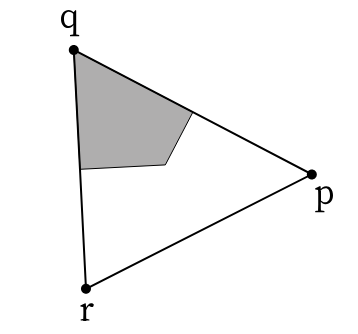
Source: [CGAL](https://doc.cgal.org/latest/Weights/group__PkgWeightsRefVoronoiRegionWeights.html)

To compute the total area, we can sum over all half-edges $(r,p)$ opposite to a vertex $q$. 

Via this approach, one can also compute cell perimeter, etc.

In [27]:
#| export

def get_cell_areas_traversal(geommesh: msh.GeomMesh, hemesh: msh.HeMesh) -> Float[jax.Array, " n_vertices"]:
    """
    Compute areas of cells by mesh traversal (don't use for simulation, inefficient).

    Boundary vertices get area 0.
    """
    areas = np.zeros(hemesh.n_vertices)
    bdry = hemesh.is_bdry
    for v in range(hemesh.n_vertices):
        if bdry[v]:
            areas[v] = 0
        else:
            adjacent_faces = hemesh.heface[hemesh.iterate_around_vertex(v)]
            polygon = geommesh.face_positions[adjacent_faces]
            areas[v] = trig.get_polygon_area(polygon)
    return -jnp.array(areas)

def get_voronoi_areas(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh) ->Float[jax.Array, " n_vertices"]:
    """Compute Voronoi area for each vertex."""
    a = hemesh.dest[hemesh.nxt]
    b = hemesh.dest[hemesh.prv]
    c = hemesh.dest
    corner_areas = jax.vmap(trig.get_voronoi_corner_area)(
        vertices[a], vertices[b], vertices[c])
    corner_areas = jnp.where(hemesh.is_bdry_he, 0, corner_areas)
    #corner_areas = jnp.clip(corner_areas, 0) # ??
    cell_areas = adj.sum_he_to_vertex_opposite(hemesh, corner_areas)
    return cell_areas

In [28]:
## Let's use the adjacency matrix to compute the area of all cells. First, compute all corner areas

a, b, c = (hemesh.dest[hemesh.nxt], hemesh.dest[hemesh.prv], hemesh.dest)

corner_areas = jax.vmap(trig.get_voronoi_corner_area)(geommesh.vertices[a], geommesh.vertices[b], geommesh.vertices[c])
cell_areas_corner = adj.sum_he_to_vertex_opposite(hemesh, corner_areas)
cell_areas_corner = cell_areas_corner.at[hemesh.is_bdry].set(0)

In [29]:
# for comparison, compute the areas by mesh traversal

cell_areas_iterative = get_cell_areas_traversal(geommesh, hemesh)
np.abs(cell_areas_iterative-cell_areas_corner).max() # works!

np.float64(5.551115123125783e-17)

### Mean curvature

To computes the point-wise, per-vertex mean curvature of a mesh, one can use the Steiner formula
$$H_i = \frac{1}{4a_i} \sum_{j\sim i} \ell_{ij} \theta_{ij} $$
where the sum is over all $j$ neighboring $i$, $\theta_{ij}$ are the dihedral angles between the adjacent triangles, and $a_i$ is the cell area around vertex $i$.


In [30]:
#| export

def get_mean_curvature_dihedral(vertices: Float[jax.Array, "n_vertices dim"], hemesh: msh.HeMesh
                                ) ->Float[jax.Array, " n_vertices"]:

    """Compute mean curvature of triangulated mesh using Steiner approximation:
        H_i = 1/(4 A_i) * sum_j * theta_ij * l_ij
    where theta_ij is the dihedral angle between faces adjacent to edge ij, l_ij is the length of edge ij,
    and A_i is the barycentric dual cell area around vertex i.
    """
    dihedral_angles = get_dihedral_angles(vertices, hemesh)
    edge_lengths = get_he_length(vertices, hemesh)
    cell_areas = get_barycentric_cell_areas(vertices, hemesh)
    return  1/4 * adj.sum_he_to_vertex_incoming(hemesh, dihedral_angles*edge_lengths) / cell_areas

### Tangent spaces and parallel transport

In [32]:
# load a 3D mesh for testing tangent space functions

sphere = TriMesh.read_obj("../test_meshes/sphere.obj", dim=3)
hemesh_s = msh.HeMesh.from_triangles(sphere.vertices.shape[0], sphere.faces)
geommesh_s = msh.GeomMesh(*hemesh_s.n_items, sphere.vertices, sphere.face_positions)

  o Icosphere


In [33]:
#| export

def get_corner_scaled_angles(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh
                             ) -> Float[jax.Array, " n_hes"]:
    """Corner angles rescaled so they sum to 2π at interior vertices and π at boundary vertices.

    Uses the same indexing convention as `get_corner_angles`: scaled_angles[he] is the
    rescaled angle at vertex dest[nxt[he]] (the vertex opposite halfedge he).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Rescaled corner angles per halfedge.
    """
    angles = get_corner_angles(vertices, hemesh)
    angle_sums = get_angle_sum(vertices, hemesh)
    # scale factor: 2π/sum at interior, π/sum at boundary
    target = jnp.where(hemesh.is_bdry, jnp.pi, 2 * jnp.pi)
    scale = target / jnp.clip(angle_sums, 1e-10)
    # corner_angles[he] is the angle at vertex dest[nxt[he]]
    vertex_of_corner = hemesh.dest[hemesh.nxt]
    return angles * scale[vertex_of_corner]

In [34]:
# test: scaled angles should sum to 2π at interior vertices
scaled = get_corner_scaled_angles(geommesh_s.vertices, hemesh_s)
scaled_sums = adj.sum_he_to_vertex_opposite(hemesh_s, scaled)
interior = ~hemesh_s.is_bdry
print("Scaled angle sum at interior vertices (should be 2π):",
      scaled_sums[interior][:5], "expected:", 2*jnp.pi)
assert jnp.allclose(scaled_sums[interior], 2*jnp.pi, atol=1e-10)

# for disk mesh (has boundary)
scaled_disk = get_corner_scaled_angles(geommesh.vertices, hemesh)
scaled_sums_disk = adj.sum_he_to_vertex_opposite(hemesh, scaled_disk)
bdry = hemesh.is_bdry
print("Scaled angle sum at boundary vertices (should be π):",
      scaled_sums_disk[bdry][:5], "expected:", jnp.pi)
assert jnp.allclose(scaled_sums_disk[bdry], jnp.pi, atol=1e-10)

Scaled angle sum at interior vertices (should be 2π): [6.28318531 6.28318531 6.28318531 6.28318531 6.28318531] expected: 6.283185307179586
Scaled angle sum at boundary vertices (should be π): [3.14159265 3.14159265 3.14159265 3.14159265 3.14159265] expected: 3.141592653589793


In [35]:
#| export

def get_normal_projector(normal: Float[jax.Array, "3"]) -> Float[jax.Array, "3 3"]:
    """Tangent-plane projector matrix P = I - n⊗n for a unit normal n.

    Parameters
    ----------
    normal : Float[Array, "3"]
        Unit normal vector.

    Returns
    -------
    Float[Array, "3 3"]
        Projection matrix onto the tangent plane.
    """
    return jnp.eye(3) - jnp.outer(normal, normal)

In [36]:
# test: projector should be idempotent and kill the normal
n = jnp.array([0., 0., 1.])
P = get_normal_projector(n)
assert jnp.allclose(P @ P, P, atol=1e-10)
assert jnp.allclose(P @ n, jnp.zeros(3), atol=1e-10)
# tangent vector should pass through
t = jnp.array([1., 2., 0.])
assert jnp.allclose(P @ t, t, atol=1e-10)

In [37]:
#| export

def _he_vectors_in_face_single(lAB: float, lBC: float, lCA: float,
                                area: float) -> Float[jax.Array, "3 2"]:
    """Compute the three halfedge vectors in the 2D face frame for one triangle.

    Convention: first vertex at origin, face_incident halfedge (A→B) along x-axis.

    Returns
    -------
    Float[Array, "3 2"]
        Rows are vectors for halfedges AB, BC, CA in the face's 2D frame.
    """
    pB = jnp.array([lAB, 0.])
    h = 2. * area / jnp.clip(lAB, 1e-10)
    w2 = jnp.clip(lCA * lCA - h * h, 0.)
    w = jnp.sqrt(w2)
    # sign: if obtuse at B (i.e. lBC² > lAB² + lCA²), flip w
    w = jnp.where(lBC * lBC > lAB * lAB + lCA * lCA, -w, w)
    pC = jnp.array([w, h])
    vecAB = pB           # A→B = pB - (0,0)
    vecBC = pC - pB      # B→C
    vecCA = -pC           # C→A = (0,0) - pC
    return jnp.stack([vecAB, vecBC, vecCA])

def get_he_vectors_in_face(vertices: Float[jax.Array, "n_vertices dim"],
                           hemesh: msh.HeMesh
                           ) -> Float[jax.Array, "n_hes 2"]:
    """Halfedge vectors in the local 2D tangent frame of each face.

    The face frame is defined with vertex A at origin and halfedge A→B along the x-axis,
    where A→B is the face's incident halfedge (face_incident[f]).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes 2"]
        2D vector per halfedge in its face's local frame. Boundary halfedges are NaN.
    """
    he_lengths = get_he_length(vertices, hemesh)
    areas = get_triangle_areas(vertices, hemesh)

    # for each face, get the three halfedge indices
    fi = hemesh.face_incident                          # n_faces
    he0 = fi                                            # AB
    he1 = hemesh.nxt[fi]                                # BC
    he2 = hemesh.nxt[hemesh.nxt[fi]]                    # CA

    lAB = he_lengths[he0]
    lBC = he_lengths[he1]
    lCA = he_lengths[he2]

    # vmap over faces
    vecs_per_face = jax.vmap(_he_vectors_in_face_single)(lAB, lBC, lCA, areas)
    # vecs_per_face: (n_faces, 3, 2) — rows 0,1,2 correspond to he0, he1, he2

    result = jnp.full((hemesh.n_hes, 2), jnp.nan)
    result = result.at[he0].set(vecs_per_face[:, 0])
    result = result.at[he1].set(vecs_per_face[:, 1])
    result = result.at[he2].set(vecs_per_face[:, 2])
    return result

In [38]:
# test on sphere mesh
he_vecs_face = get_he_vectors_in_face(geommesh_s.vertices, hemesh_s)

# check: per-face sum of halfedge vectors should be zero (triangle closes)
fi = hemesh_s.face_incident
face_sum = he_vecs_face[fi] + he_vecs_face[hemesh_s.nxt[fi]] + he_vecs_face[hemesh_s.nxt[hemesh_s.nxt[fi]]]
print("Max face vector sum (should be ~0):", jnp.abs(face_sum).max())
assert jnp.allclose(face_sum, 0., atol=1e-10)

# check: norms should match edge lengths
he_lengths = get_he_length(geommesh_s.vertices, hemesh_s)
# only check interior halfedges
interior_he = hemesh_s.heface >= 0
norms = jnp.linalg.norm(he_vecs_face, axis=-1)
print("Max length error:", jnp.abs(norms[interior_he] - he_lengths[interior_he]).max())
assert jnp.allclose(norms[interior_he], he_lengths[interior_he], atol=1e-10)

TypeCheckError: Type-check error whilst checking the parameters of __main__._he_vectors_in_face_single.
The problem arose whilst typechecking parameter 'lAB'.
Actual value: f64[]
Expected type: <class 'float'>.
----------------------
Called with parameters: {'lAB': f64[], 'lBC': f64[], 'lCA': f64[], 'area': f64[]}
Parameter annotations: (lAB: float, lBC: float, lCA: float, area: float) -> Any.


In [ ]:
#| export

def get_transport_across_halfedge(vertices: Float[jax.Array, "n_vertices dim"],
                                  hemesh: msh.HeMesh
                                  ) -> Float[jax.Array, " n_hes"]:
    """Rotation angle to transport a tangent vector from one face to the adjacent face across a halfedge.

    Applying this rotation to a vector in the frame of heface[he] gives the same vector
    in the frame of heface[twin[he]].

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Transport angle per halfedge (radians). NaN for boundary halfedges.
    """
    he_vecs = get_he_vectors_in_face(vertices, hemesh)

    vecA = he_vecs                        # shared edge in face of he
    vecB = he_vecs[hemesh.twin]           # same edge in face of twin (opposite direction)

    # transport angle: rotation from vecA to -vecB
    transport = jax.vmap(trig.get_signed_angle_between_vectors)(vecA, -vecB)

    # mask boundary halfedges
    is_bdry_he = hemesh.heface < 0
    is_bdry_twin = hemesh.heface[hemesh.twin] < 0
    transport = jnp.where(is_bdry_he | is_bdry_twin, jnp.nan, transport)
    return transport

In [39]:
# test: transport[he] should be -transport[twin[he]] (anti-symmetry)
transport_face = get_transport_across_halfedge(geommesh_s.vertices, hemesh_s)
interior_he = (hemesh_s.heface >= 0) & (hemesh_s.heface[hemesh_s.twin] >= 0)
print("Max anti-symmetry error:",
      jnp.abs(transport_face[interior_he] + transport_face[hemesh_s.twin[interior_he]]).max())
assert jnp.allclose(transport_face[interior_he],
                     -transport_face[hemesh_s.twin[interior_he]], atol=1e-10)

NameError: name 'get_transport_across_halfedge' is not defined

In [40]:
#| export

def get_he_vectors_in_vertex(vertices: Float[jax.Array, "n_vertices dim"],
                             hemesh: msh.HeMesh
                             ) -> Float[jax.Array, "n_hes 2"]:
    """Halfedge vectors in the local 2D tangent frame of each source vertex.

    The vertex frame is defined by walking counterclockwise around each vertex,
    accumulating rescaled corner angles. The incident halfedge of each vertex
    is aligned with the x-axis (angle = 0).

    Note: uses Python loops over vertices (not JIT-compatible). The returned
    array can be used in JIT-compiled downstream code.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes 2"]
        2D vector per halfedge in its source vertex's local frame.
    """
    he_lengths = get_he_length(vertices, hemesh)
    scaled_angles = get_corner_scaled_angles(vertices, hemesh)

    # accumulate angles using numpy, then convert
    cumulative_angles = np.zeros(hemesh.n_hes)

    for v in range(hemesh.n_vertices):
        outgoing_hes = hemesh.iterate_around_vertex(v)
        # angle at v (= orig[he]) in the face of each outgoing he is scaled_angles[nxt[he]]
        angles_at_v = np.array(scaled_angles[hemesh.nxt[outgoing_hes]])
        cum = np.concatenate([[0.], np.cumsum(angles_at_v[:-1])])
        cumulative_angles[np.array(outgoing_hes)] = cum

    cumulative_angles = jnp.array(cumulative_angles)
    return (jnp.stack([jnp.cos(cumulative_angles),
                       jnp.sin(cumulative_angles)], axis=-1)
            * he_lengths[:, None])

In [41]:
# test: norms should match edge lengths
he_vecs_vtx = get_he_vectors_in_vertex(geommesh_s.vertices, hemesh_s)
he_lengths_s = get_he_length(geommesh_s.vertices, hemesh_s)
norms_vtx = jnp.linalg.norm(he_vecs_vtx, axis=-1)
print("Max vertex he-vector length error:", jnp.abs(norms_vtx - he_lengths_s).max())
assert jnp.allclose(norms_vtx, he_lengths_s, atol=1e-10)

Max vertex he-vector length error: 1.1102230246251565e-16


In [42]:
#| export

def get_transport_along_halfedge(vertices: Float[jax.Array, "n_vertices dim"],
                                 hemesh: msh.HeMesh
                                 ) -> Float[jax.Array, " n_hes"]:
    """Rotation angle to transport a tangent vector from the source vertex to the target vertex of a halfedge.

    Applying this rotation to a vector in the tangent frame of orig[he] gives the same
    vector in the tangent frame of dest[he] (= orig[twin[he]]).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices dim"]
        Vertex positions.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_hes"]
        Transport angle per halfedge (radians).
    """
    he_vecs = get_he_vectors_in_vertex(vertices, hemesh)

    vecA = he_vecs                        # he in frame of orig[he]
    vecB = he_vecs[hemesh.twin]           # twin in frame of dest[he] = orig[twin[he]]

    # transport angle: rotation from vecA to -vecB
    return jax.vmap(trig.get_signed_angle_between_vectors)(vecA, -vecB)

In [43]:
# test: transport[he] = -transport[twin[he]] (anti-symmetry)
transport_vtx = get_transport_along_halfedge(geommesh_s.vertices, hemesh_s)
print("Max vertex anti-symmetry error:",
      jnp.abs(transport_vtx + transport_vtx[hemesh_s.twin]).max())
assert jnp.allclose(transport_vtx, -transport_vtx[hemesh_s.twin], atol=1e-10)

Max vertex anti-symmetry error: 4.440892098500626e-16


In [44]:
#| export

def get_face_tangent_basis(vertices: Float[jax.Array, "n_vertices 3"],
                           hemesh: msh.HeMesh
                           ) -> Float[jax.Array, "n_faces 2 3"]:
    """Orthonormal tangent basis (basisX, basisY) in 3D world coordinates per face.

    Convention: basisX is aligned with the face's incident halfedge projected onto
    the face tangent plane. basisY = cross(face_normal, basisX).

    Parameters
    ----------
    vertices : Float[Array, "n_vertices 3"]
        Vertex positions in 3D.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_faces 2 3"]
        Per-face tangent basis: result[f, 0] = basisX, result[f, 1] = basisY.
    """
    normals = get_triangle_normals(vertices, hemesh)

    # edge vector of face incident halfedge
    fi = hemesh.face_incident
    edge_vec = vertices[hemesh.dest[fi]] - vertices[hemesh.orig[fi]]

    # project onto tangent plane and normalize
    def _basis(edge, normal):
        proj = edge - normal * jnp.dot(edge, normal)
        bx = proj / jnp.clip(jnp.linalg.norm(proj), 1e-10)
        by = jnp.cross(normal, bx)
        return jnp.stack([bx, by])

    return jax.vmap(_basis)(edge_vec, normals)

In [45]:
# test: face tangent basis orthonormality
face_basis = get_face_tangent_basis(geommesh_s.vertices, hemesh_s)
bx, by = face_basis[:, 0], face_basis[:, 1]
face_normals = get_triangle_normals(geommesh_s.vertices, hemesh_s)

# bx · by ≈ 0, |bx| ≈ 1, |by| ≈ 1
print("Max bx·by:", jnp.abs(jax.vmap(jnp.dot)(bx, by)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx, by), 0., atol=1e-10)
assert jnp.allclose(jnp.linalg.norm(bx, axis=-1), 1., atol=1e-10)
assert jnp.allclose(jnp.linalg.norm(by, axis=-1), 1., atol=1e-10)

# bx and by should be orthogonal to face normal
print("Max bx·n:", jnp.abs(jax.vmap(jnp.dot)(bx, face_normals)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx, face_normals), 0., atol=1e-10)
assert jnp.allclose(jax.vmap(jnp.dot)(by, face_normals), 0., atol=1e-10)

# cross-check: basisX * vx + basisY * vy ≈ projected 3D edge vector for incident he
fi = hemesh_s.face_incident
edge_3d = geommesh_s.vertices[hemesh_s.dest[fi]] - geommesh_s.vertices[hemesh_s.orig[fi]]
he_vecs_2d = get_he_vectors_in_face(geommesh_s.vertices, hemesh_s)
vx, vy = he_vecs_2d[fi, 0], he_vecs_2d[fi, 1]
reconstructed = bx * vx[:, None] + by * vy[:, None]
print("Max 3D reconstruction error:", jnp.abs(reconstructed - edge_3d).max())
assert jnp.allclose(reconstructed, edge_3d, atol=1e-8)

Max bx·by: 9.71445146547012e-17
Max bx·n: 5.93629416659658e-17


TypeCheckError: Type-check error whilst checking the parameters of __main__._he_vectors_in_face_single.
The problem arose whilst typechecking parameter 'lAB'.
Actual value: f64[]
Expected type: <class 'float'>.
----------------------
Called with parameters: {'lAB': f64[], 'lBC': f64[], 'lCA': f64[], 'area': f64[]}
Parameter annotations: (lAB: float, lBC: float, lCA: float, area: float) -> Any.


In [46]:
#| export

def get_vertex_tangent_basis(vertices: Float[jax.Array, "n_vertices 3"],
                             hemesh: msh.HeMesh
                             ) -> Float[jax.Array, "n_vertices 2 3"]:
    """Orthonormal tangent basis (basisX, basisY) in 3D world coordinates per vertex.

    Computed by projecting each outgoing edge vector onto the vertex tangent plane,
    rotating by the negative of the intrinsic angle to extract the x-contribution,
    and averaging over all incident edges.

    Parameters
    ----------
    vertices : Float[Array, "n_vertices 3"]
        Vertex positions in 3D.
    hemesh : HeMesh
        Half-edge mesh.

    Returns
    -------
    Float[Array, "n_vertices 2 3"]
        Per-vertex tangent basis: result[v, 0] = basisX, result[v, 1] = basisY.
    """
    vtx_normals = get_vertex_normals(vertices, hemesh)
    he_vecs_vtx = get_he_vectors_in_vertex(vertices, hemesh)

    # for each outgoing halfedge: project 3D edge vector to tangent plane, rotate by -angle
    edge_3d = vertices[hemesh.dest] - vertices[hemesh.orig]                        # (n_hes, 3)
    normals_at_orig = vtx_normals[hemesh.orig]                                      # (n_hes, 3)

    # project edge vectors to tangent plane
    proj = edge_3d - normals_at_orig * jnp.sum(edge_3d * normals_at_orig, axis=-1, keepdims=True)

    # intrinsic angle of each he in vertex frame
    angles = jnp.arctan2(he_vecs_vtx[:, 1], he_vecs_vtx[:, 0])

    # rotate by -angle around vertex normal to extract x-contribution
    bx_contributions = jax.vmap(trig.rotate_around_axis)(proj, normals_at_orig, -angles)

    # sum contributions and normalize per vertex
    bx_sum = adj.sum_he_to_vertex_incoming(hemesh, bx_contributions)
    bx_norm = jnp.clip(jnp.linalg.norm(bx_sum, axis=-1, keepdims=True), 1e-10)
    bx = bx_sum / bx_norm
    by = jax.vmap(jnp.cross)(vtx_normals, bx)
    return jnp.stack([bx, by], axis=1)

In [47]:
# test: vertex tangent basis orthonormality
vtx_basis = get_vertex_tangent_basis(geommesh_s.vertices, hemesh_s)
bx_v, by_v = vtx_basis[:, 0], vtx_basis[:, 1]
vtx_normals = get_vertex_normals(geommesh_s.vertices, hemesh_s)

print("Max bx·by:", jnp.abs(jax.vmap(jnp.dot)(bx_v, by_v)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx_v, by_v), 0., atol=1e-8)
assert jnp.allclose(jnp.linalg.norm(bx_v, axis=-1), 1., atol=1e-8)
assert jnp.allclose(jnp.linalg.norm(by_v, axis=-1), 1., atol=1e-8)

# orthogonal to vertex normal
print("Max bx·n:", jnp.abs(jax.vmap(jnp.dot)(bx_v, vtx_normals)).max())
assert jnp.allclose(jax.vmap(jnp.dot)(bx_v, vtx_normals), 0., atol=1e-8)
assert jnp.allclose(jax.vmap(jnp.dot)(by_v, vtx_normals), 0., atol=1e-8)

Max bx·by: 8.250778532614689e-17


AssertionError: 